<a href="https://colab.research.google.com/github/obaidur2020/30_Days_Machine_Learning/blob/main/predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)

# Models
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Imbalanced data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Save model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Random seed
RANDOM_STATE = 42

In [ ]:
# ─── STEP 2: LOAD DATA ───────────────────────────────────────────────────────
df = pd.read_csv('/content/drive/MyDrive/Thesis/CVD/ECG FinalData.csv')

print(f"Shape: {df.shape}")
print(df.info())
print(df.describe(include='all'))

Shape: (7617, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7617 entries, 0 to 7616
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PatientId     7617 non-null   int64  
 1   PatientAge    7617 non-null   int64  
 2   Cycle         7617 non-null   int64  
 3   P_wave        7617 non-null   float64
 4   Q_wave        7617 non-null   float64
 5   R_wave        7617 non-null   float64
 6   S_wave        7617 non-null   float64
 7   T_wave        7617 non-null   float64
 8   PR_Interval   7617 non-null   float64
 9   QRS_Complex   7617 non-null   float64
 10  RR_Interval   7617 non-null   float64
 11  QT_Interval   7617 non-null   float64
 12  QTc_Interval  7617 non-null   float64
 13  ST _segment   7617 non-null   float64
dtypes: float64(11), int64(3)
memory usage: 833.2 KB
None
         PatientId   PatientAge        Cycle        P_wave        Q_wave  \
count  7617.000000  7617.000000  7617.000000   7617.0

In [ ]:
# ==============================
# CHECK NULL VALUES
# ==============================

print(df.isnull().sum())

PatientId       0
PatientAge      0
Cycle           0
P_wave          0
Q_wave          0
R_wave          0
S_wave          0
T_wave          0
PR_Interval     0
QRS_Complex     0
RR_Interval     0
QT_Interval     0
QTc_Interval    0
ST _segment     0
dtype: int64


In [ ]:
# ==============================
# CHECK AVAILABLE COLUMNS
# ==============================

print("Dataset Columns:\n")
print(df.columns.tolist())

# ==============================
# DEFINE TARGET COLUMN
# ==============================

target_column = 'Risk_Level'   # CHANGE THIS if needed

# Leakage features
leakage_features = [
    'QRS_Complex',
    'RR_Interval',
    'P_wave'
]

# Keep only columns that actually exist
existing_leakage = [
    col for col in leakage_features
    if col in df.columns
]

print("\nExisting leakage features:")
print(existing_leakage)

# Drop safely
X = df.drop(
    columns=[target_column] + existing_leakage,
    errors='ignore'
)

# Target
y = df[target_column]

print("\nFinal Features:")
print(X.columns)

Dataset Columns:

['PatientId', 'PatientAge', 'Cycle', 'P_wave', 'Q_wave', 'R_wave', 'S_wave', 'T_wave', 'PR_Interval', 'QRS_Complex', 'RR_Interval', 'QT_Interval', 'QTc_Interval', 'ST _segment']

Existing leakage features:
['QRS_Complex', 'RR_Interval', 'P_wave']


KeyError: 'Risk_Level'

In [ ]:
# ==============================
# TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(X_train.shape)
print(X_test.shape)

NameError: name 'X' is not defined

In [ ]:
# ─── STEP 6: CORRECT PIPELINE — SPLIT FIRST, SMOTE AFTER ────────────────────

# Features & Target
X_raw = df_cleaned.drop(columns=['Risk_level'])
y_raw = df_cleaned['Risk_level']

# Drop leakage features (used to create Risk_level label)
leakage_features = ['QRS_Complex', 'RR_Interval', 'P_wave']
X_raw = X_raw.drop(columns=[c for c in leakage_features if c in X_raw.columns])

print(f"Features after leakage fix : {X_raw.columns.tolist()}")
print(f"Class distribution         : {y_raw.value_counts().to_dict()}")

# ── Step 6a: Split FIRST (original data, no SMOTE yet) ──
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_raw
)

# ── Step 6b: Scale (fit on train only) ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)    # transform only, no fit

# ── Step 6c: SMOTE only on Train set ──
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train_scaled, y_train_raw)

# Test set stays original — no SMOTE
X_test = X_test_scaled
y_test = y_test_raw

print(f"\n✅ Correct Pipeline:")
print(f"Train before SMOTE : {y_train_raw.value_counts().to_dict()}")
print(f"Train after  SMOTE : {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test  (original)   : {y_test.value_counts().to_dict()}")
print(f"\nTrain shape : {X_train.shape}")
print(f"Test  shape : {X_test.shape}")

Features after leakage fix : ['PatientAge', 'Q_wave', 'R_wave', 'S_wave', 'T_wave', 'PR_Interval', 'QT_Interval', 'QTc_Interval', 'ST _segment']
Class distribution         : {0: 6621, 1: 996}

✅ Correct Pipeline:
Train before SMOTE : {0: 5296, 1: 797}
Train after  SMOTE : {1: 5296, 0: 5296}
Test  (original)   : {0: 1325, 1: 199}

Train shape : (10592, 9)
Test  shape : (1524, 9)


Mutual Information Scores:
Q_wave          0.592575
T_wave          0.576735
S_wave          0.571662
R_wave          0.562703
PR_Interval     0.547347
QT_Interval     0.486158
QTc_Interval    0.357570
PatientAge      0.055057
ST _segment     0.054949
dtype: float64


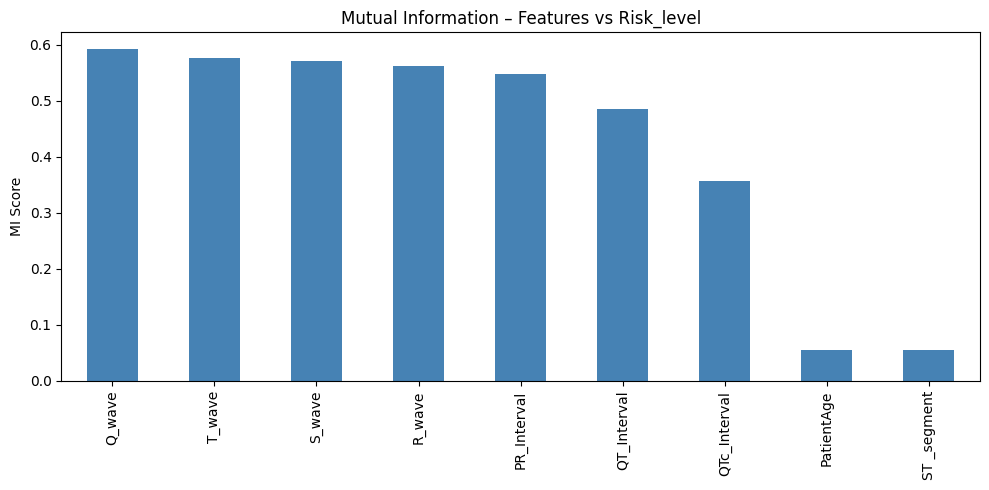

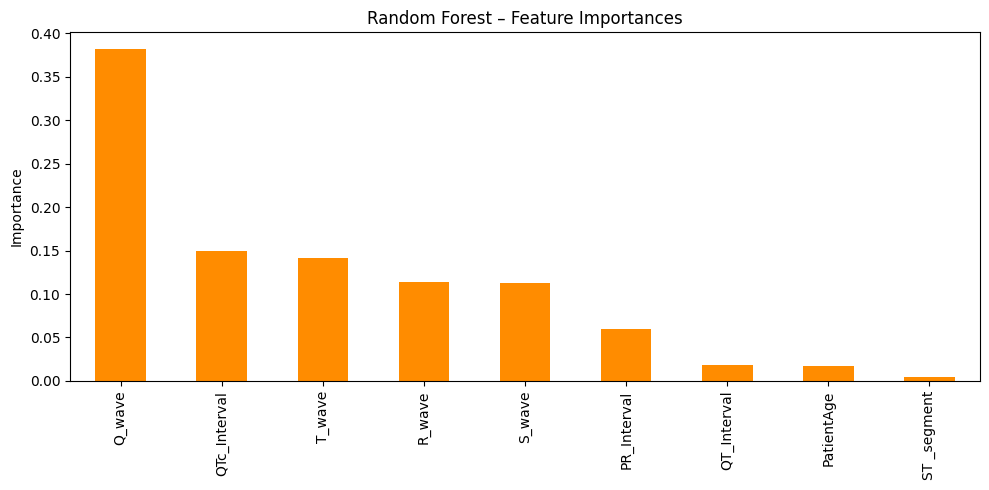


Force-kept                  : ['ST _segment', 'PatientAge']
Dropped                     : ['QT_Interval']
Final features (8): ['PatientAge', 'Q_wave', 'R_wave', 'S_wave', 'T_wave', 'PR_Interval', 'QTc_Interval', 'ST _segment']

Train shape : (10592, 8)
Test  shape : (1524, 8)


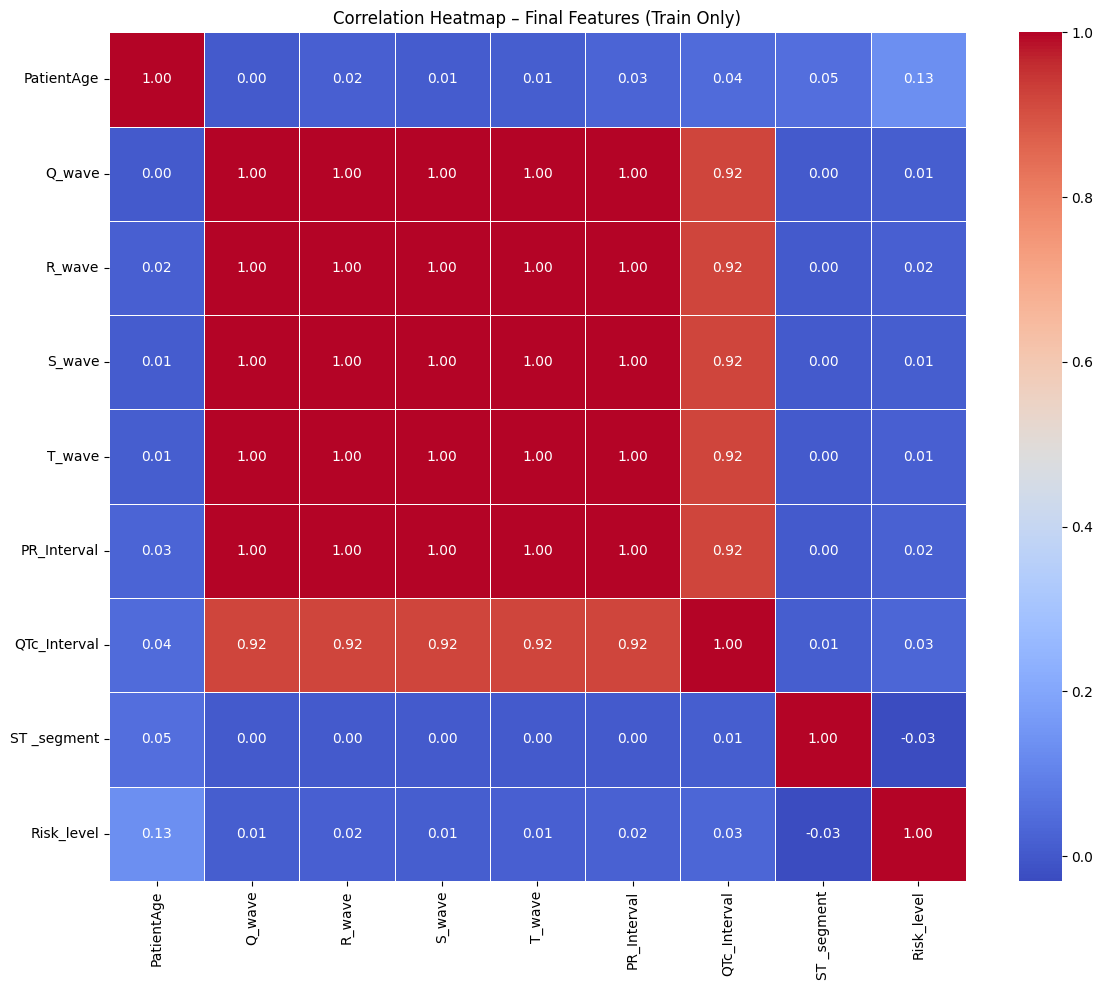


Highly correlated pairs (>0.95): [('Q_wave', 'R_wave'), ('Q_wave', 'S_wave'), ('Q_wave', 'T_wave'), ('R_wave', 'S_wave'), ('R_wave', 'T_wave'), ('S_wave', 'T_wave'), ('PR_Interval', 'Q_wave'), ('PR_Interval', 'R_wave'), ('PR_Interval', 'S_wave'), ('PR_Interval', 'T_wave')]


In [ ]:
# ─── STEP 7: FEATURE ANALYSIS (Train data only) ───────────────────────────────
X_feat = pd.DataFrame(X_train, columns=X_raw.columns)
y_feat = pd.Series(y_train)

# Mutual Information
mi_scores = mutual_info_classif(X_feat, y_feat, random_state=42)
mi_series = pd.Series(mi_scores, index=X_feat.columns).sort_values(ascending=False)

print("Mutual Information Scores:")
print(mi_series)

plt.figure(figsize=(10, 5))
mi_series.plot(kind='bar', color='steelblue')
plt.title('Mutual Information – Features vs Risk_level')
plt.ylabel('MI Score')
plt.tight_layout()
plt.show()

# Random Forest Feature Importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_feat, y_feat)

feat_imp = pd.Series(rf.feature_importances_,
                     index=X_feat.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='darkorange')
plt.title('Random Forest – Feature Importances')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

# Keep all features (already removed leakage)
# Must-keep clinically important
must_keep = [c for c in ['ST _segment', 'PatientAge'] if c in X_feat.columns]

drop_feats = [
    f for f in feat_imp[feat_imp < 0.05].index.tolist()
    if f not in must_keep
]

# Apply drop on both train and test
selected_features = [c for c in X_feat.columns if c not in drop_feats]
col_idx           = [list(X_feat.columns).index(c) for c in selected_features]

X_train = X_train[:, col_idx]
X_test  = X_test[:, col_idx]

print(f"\nForce-kept                  : {must_keep}")
print(f"Dropped                     : {drop_feats if drop_feats else 'None'}")
print(f"Final features ({len(selected_features)}): {selected_features}")
print(f"\nTrain shape : {X_train.shape}")
print(f"Test  shape : {X_test.shape}")

# Correlation Heatmap
df_corr = pd.DataFrame(X_train, columns=selected_features)
df_corr['Risk_level'] = y_train

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap – Final Features (Train Only)')
plt.tight_layout()
plt.show()

# Leakage Check
cor_matrix = df_corr.corr().abs()
leak_pairs = [
    (i, j) for i in cor_matrix.columns
    for j in cor_matrix.columns
    if i < j and cor_matrix.loc[i, j] > 0.95
]
print(f"\nHighly correlated pairs (>0.95): "
      f"{leak_pairs if leak_pairs else 'None found ✓'}")

# Store feature names
feature_names = selected_features

In [ ]:
# ─── STEP 8: SUMMARY ─────────────────────────────────────────────────────────
print("=" * 55)
print("         FINAL DATA SUMMARY")
print("=" * 55)
print(f"Features used    : {feature_names}")
print(f"Train samples    : {X_train.shape[0]}")
print(f"Test  samples    : {X_test.shape[0]}")
print(f"Train class dist : {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test  class dist : {pd.Series(y_test).value_counts().to_dict()}")

         FINAL DATA SUMMARY
Features used    : ['PatientAge', 'Q_wave', 'R_wave', 'S_wave', 'T_wave', 'PR_Interval', 'QTc_Interval', 'ST _segment']
Train samples    : 10592
Test  samples    : 1524
Train class dist : {1: 5296, 0: 5296}
Test  class dist : {0: 1325, 1: 199}


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 3.2 MB/s eta 0:00:00
       ALL MODEL BENCHMARKS (sorted by Accuracy)
                               Accuracy  Balanced Accuracy   ROC AUC  F1 Score  Precision    Recall  Time Taken
Model                                                                                                          
LGBMClassifier                 0.992126           0.980525  0.999333  0.992109   0.992100  0.992126    0.397899
ExtraTreesClassifier           0.991470           0.980148  0.991184  0.991461   0.991453  0.991470    0.705901
BaggingClassifier              0.991470           0.980148  0.996524  0.991461   0.991453  0.991470    0.160026
RandomForestClassifier         0.991470           0.980148  0.998511  0.991461   0.991453  0.991470    0.683439
DecisionTreeClassifier         0.991470           0.980148  0.988875  0.991461   0.991453  0.991470    0.060585
ExtraTreeClassifier            0.991470           0.978013  0.983808  0.991442   0.991431

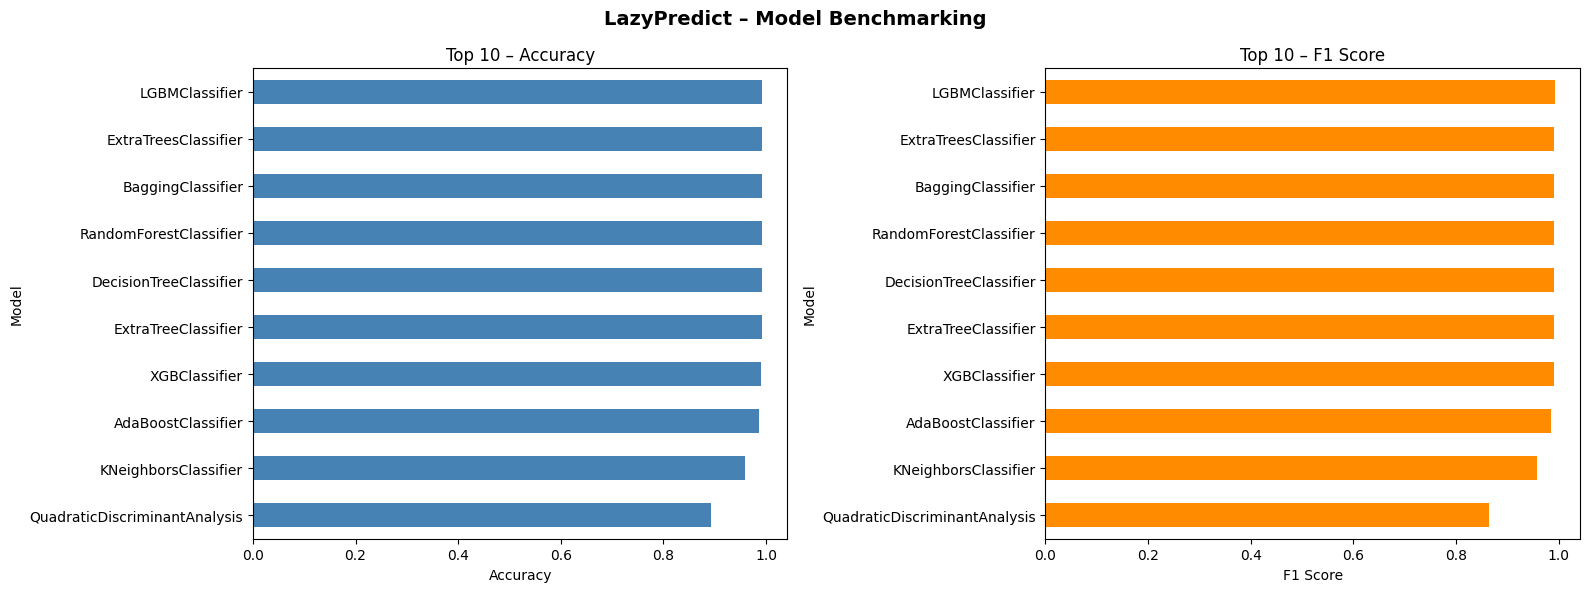

In [ ]:
# ─── STEP 9: LAZYPREDICT BENCHMARKING ────────────────────────────────────────
!pip install -q lazypredict

from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# Sort by Accuracy descending
models_sorted = models.sort_values("Accuracy", ascending=False)

print("=" * 60)
print("       ALL MODEL BENCHMARKS (sorted by Accuracy)")
print("=" * 60)
print(models_sorted.to_string())

# Top 5 models
print("\n" + "=" * 60)
print("              TOP 5 MODELS")
print("=" * 60)
print(models_sorted.head(5).to_string())

# Visualize Top 10
top10 = models_sorted.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10['Accuracy'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 – Accuracy')
axes[0].set_xlabel('Accuracy')
axes[0].invert_yaxis()

top10['F1 Score'].plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 10 – F1 Score')
axes[1].set_xlabel('F1 Score')
axes[1].invert_yaxis()

plt.suptitle('LazyPredict – Model Benchmarking', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print(f"Training samples: {X_train.shape[0]}")

Training samples: 10593


Running XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:55:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



   XGBoost
              precision    recall  f1-score   support

    Low Risk       0.99      1.00      1.00      1325
   High Risk       0.98      0.96      0.97       199

    accuracy                           0.99      1524
   macro avg       0.99      0.98      0.98      1524
weighted avg       0.99      0.99      0.99      1524

Train Accuracy   : 0.9949
Test  Accuracy   : 0.9921
CV F1 (mean±std) : 0.9925 ± 0.0010
AUC Score        : 0.9991

Overfit Gap (Train - Test): 0.0028
✅ No Overfitting — Model is stable


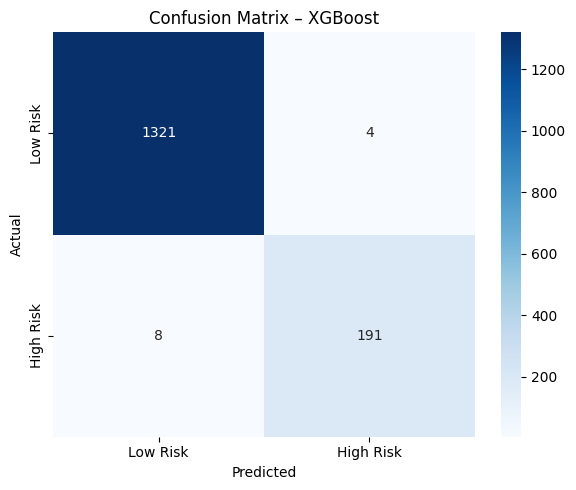

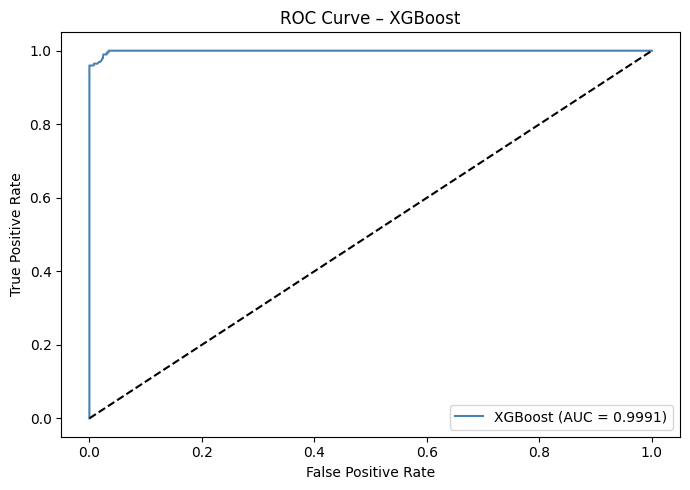

Running LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



   LightGBM
              precision    recall  f1-score   support

    Low Risk       0.99      1.00      1.00      1325
   High Risk       0.98      0.96      0.97       199

    accuracy                           0.99      1524
   macro avg       0.99      0.98      0.98      1524
weighted avg       0.99      0.99      0.99      1524

Train Accuracy   : 0.9958
Test  Accuracy   : 0.9928
CV F1 (mean±std) : 0.9945 ± 0.0005
AUC Score        : 0.9992

Overfit Gap (Train - Test): 0.0031
✅ No Overfitting — Model is stable


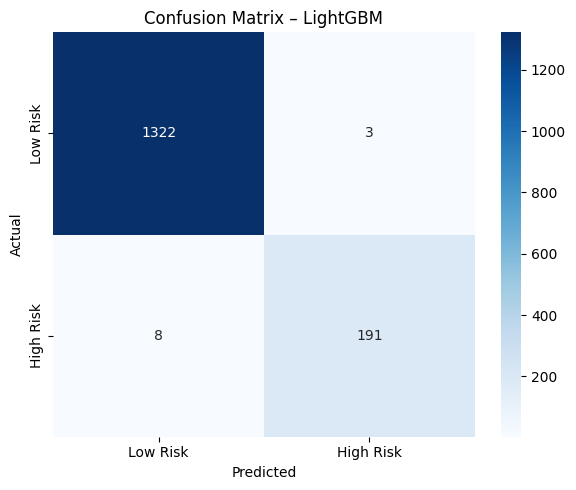

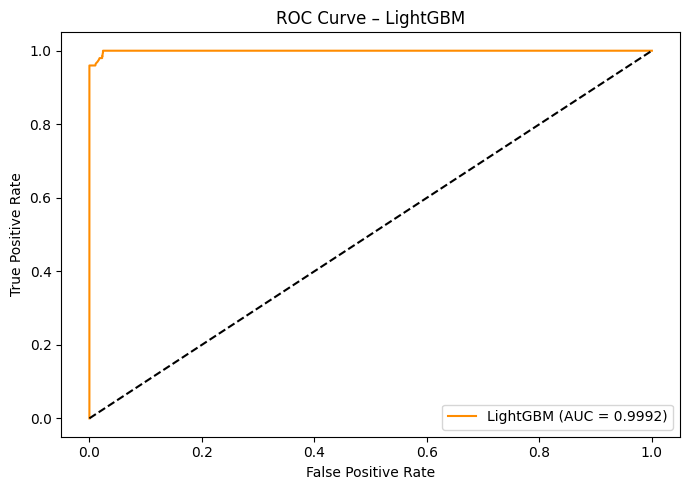

Running ExtraTreesClassifier...

   ExtraTreesClassifier
              precision    recall  f1-score   support

    Low Risk       1.00      0.96      0.98      1325
   High Risk       0.80      0.97      0.88       199

    accuracy                           0.96      1524
   macro avg       0.90      0.97      0.93      1524
weighted avg       0.97      0.96      0.97      1524

Train Accuracy   : 0.9632
Test  Accuracy   : 0.9639
CV F1 (mean±std) : 0.9598 ± 0.0075
AUC Score        : 0.9947

Overfit Gap (Train - Test): -0.0007
✅ No Overfitting — Model is stable


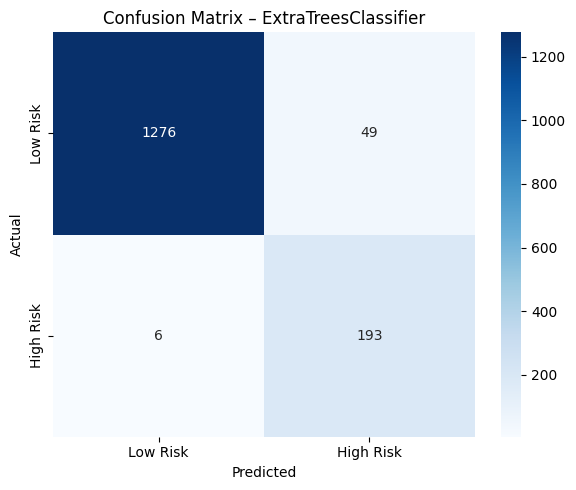

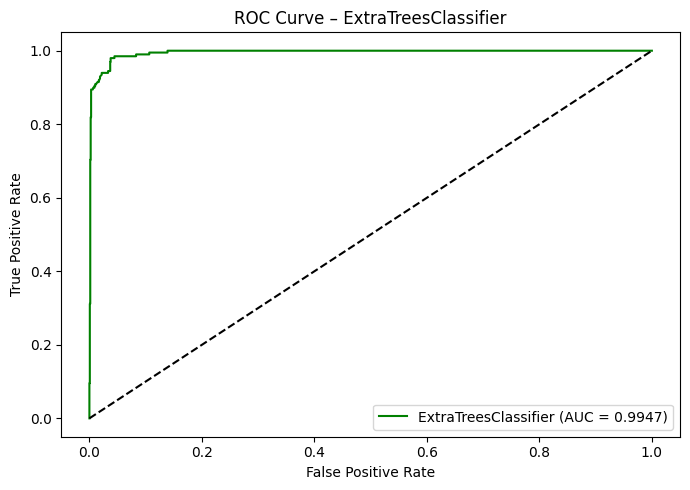


     FINAL ML COMPARISON (Correct Pipeline)
                      Train Acc  Test Acc   CV F1     AUC  Overfit Gap
Model                                                                 
XGBoost                  0.9949    0.9921  0.9925  0.9991       0.0028
LightGBM                 0.9958    0.9928  0.9945  0.9992       0.0031
ExtraTreesClassifier     0.9632    0.9639  0.9598  0.9947      -0.0007


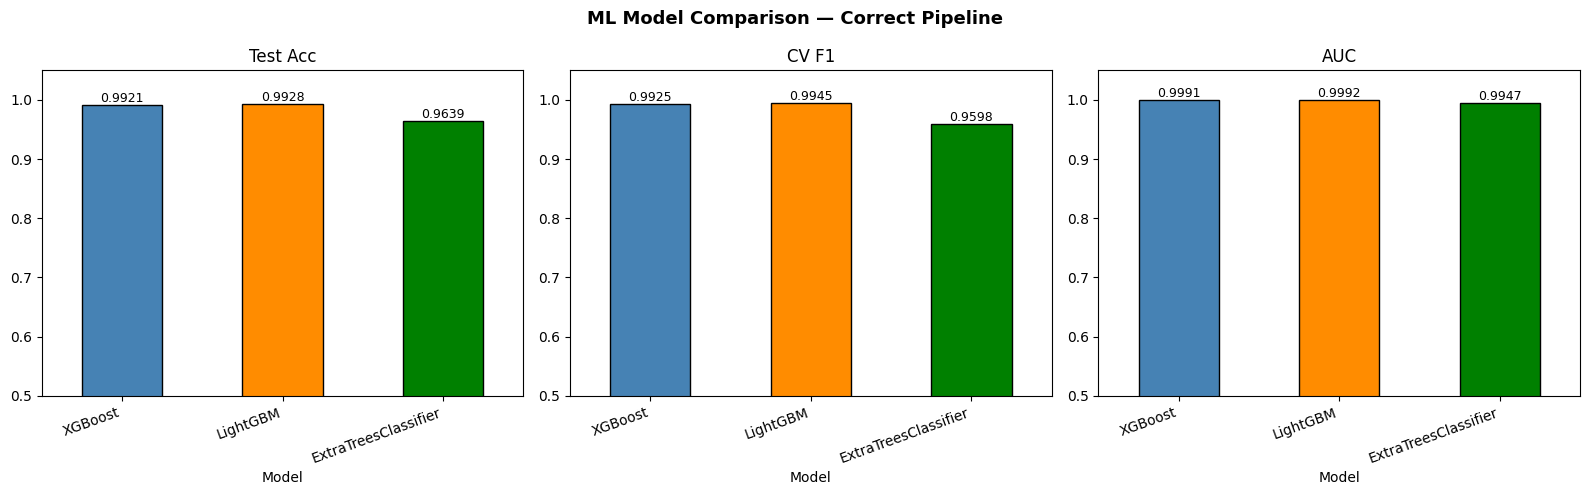

In [ ]:
# ─── 3 ML MODELS ─────────────────────────────────────────────────────────────
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, model_name, color):
    cv_scores  = cross_val_score(model, X_train, y_train,
                                 cv=cv, scoring='f1_macro', n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred     = model.predict(X_test)
    y_prob     = model.predict_proba(X_test)[:, 1]
    train_acc  = accuracy_score(y_train, model.predict(X_train))
    test_acc   = accuracy_score(y_test, y_pred)
    auc        = roc_auc_score(y_test, y_prob)
    diff       = train_acc - test_acc

    print("\n" + "=" * 55)
    print(f"   {model_name}")
    print("=" * 55)
    print(classification_report(y_test, y_pred,
          target_names=['Low Risk', 'High Risk']))
    print(f"Train Accuracy   : {train_acc:.4f}")
    print(f"Test  Accuracy   : {test_acc:.4f}")
    print(f"CV F1 (mean±std) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"AUC Score        : {auc:.4f}")
    print(f"\nOverfit Gap (Train - Test): {diff:.4f}")
    if diff < 0.02:
        print("✅ No Overfitting — Model is stable")
    elif diff < 0.05:
        print("🟡 Slight Overfitting — Acceptable")
    else:
        print("❌ Overfitting Detected — Needs tuning")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low Risk', 'High Risk'],
                yticklabels=['Low Risk', 'High Risk'])
    plt.title(f'Confusion Matrix – {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color=color,
             label=f'{model_name} (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve – {model_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        'Model'      : model_name,
        'Train Acc'  : round(train_acc, 4),
        'Test Acc'   : round(test_acc,  4),
        'CV F1'      : round(cv_scores.mean(), 4),
        'AUC'        : round(auc, 4),
        'Overfit Gap': round(diff, 4)
    }

# Define Models
xgb_model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = 42,
    n_jobs            = -1
)

lgbm_model = LGBMClassifier(
    n_estimators      = 300,
    max_depth         = 4,
    num_leaves        = 15,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1
)

et_model = ExtraTreesClassifier(
    n_estimators      = 300,
    max_depth         = 10,
    min_samples_split = 10,
    min_samples_leaf  = 5,
    max_features      = 'sqrt',
    class_weight      = 'balanced',
    random_state      = 42,
    n_jobs            = -1
)

# Run All 3
results = []

print("Running XGBoost...")
results.append(evaluate_model(xgb_model, 'XGBoost', color='steelblue'))

print("Running LightGBM...")
results.append(evaluate_model(lgbm_model, 'LightGBM', color='darkorange'))

print("Running ExtraTreesClassifier...")
results.append(evaluate_model(et_model, 'ExtraTreesClassifier', color='green'))

# Comparison Table
results_df = pd.DataFrame(results).set_index('Model')
print("\n" + "=" * 65)
print("     FINAL ML COMPARISON (Correct Pipeline)")
print("=" * 65)
print(results_df.to_string())

# Chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors  = ['steelblue', 'darkorange', 'green']
metrics = ['Test Acc', 'CV F1', 'AUC']

for i, metric in enumerate(metrics):
    results_df[metric].plot(
        kind='bar', ax=axes[i],
        color=colors, edgecolor='black', width=0.5
    )
    axes[i].set_title(metric)
    axes[i].set_ylim(0.5, 1.05)
    axes[i].set_xticklabels(results_df.index, rotation=20, ha='right')
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.4f}',
                         (p.get_x() + p.get_width() / 2, p.get_height()),
                         ha='center', va='bottom', fontsize=9)

plt.suptitle('ML Model Comparison — Correct Pipeline',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Running XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:38:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



   XGBoost
              precision    recall  f1-score   support

    Low Risk       0.95      0.98      0.96      1325
   High Risk       0.98      0.94      0.96      1324

    accuracy                           0.96      2649
   macro avg       0.96      0.96      0.96      2649
weighted avg       0.96      0.96      0.96      2649

Train Accuracy   : 0.9695
Test  Accuracy   : 0.9634
CV F1 (mean±std) : 0.9630 ± 0.0042
AUC Score        : 0.9908

Overfit Gap (Train - Test): 0.0061
✅ No Overfitting — Model is stable


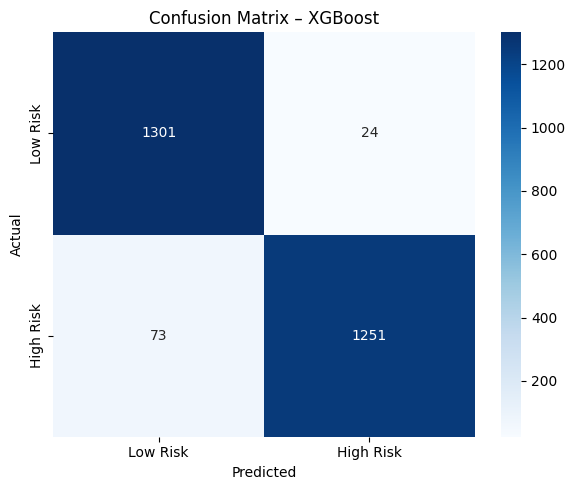

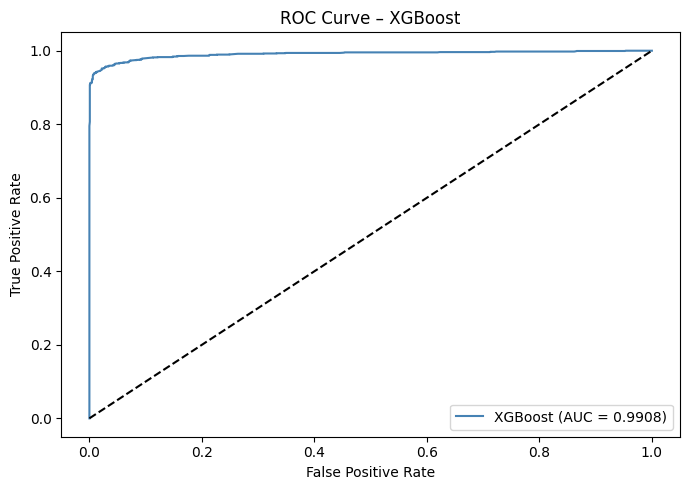

Running LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



   LightGBM
              precision    recall  f1-score   support

    Low Risk       0.96      0.99      0.97      1325
   High Risk       0.99      0.96      0.97      1324

    accuracy                           0.97      2649
   macro avg       0.97      0.97      0.97      2649
weighted avg       0.97      0.97      0.97      2649

Train Accuracy   : 0.9777
Test  Accuracy   : 0.9724
CV F1 (mean±std) : 0.9734 ± 0.0038
AUC Score        : 0.9947

Overfit Gap (Train - Test): 0.0053
✅ No Overfitting — Model is stable


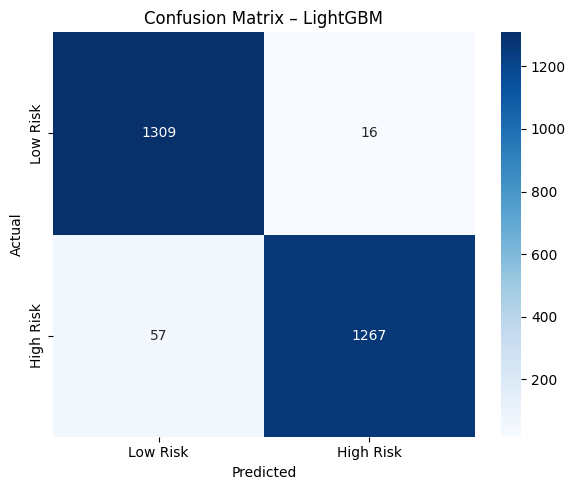

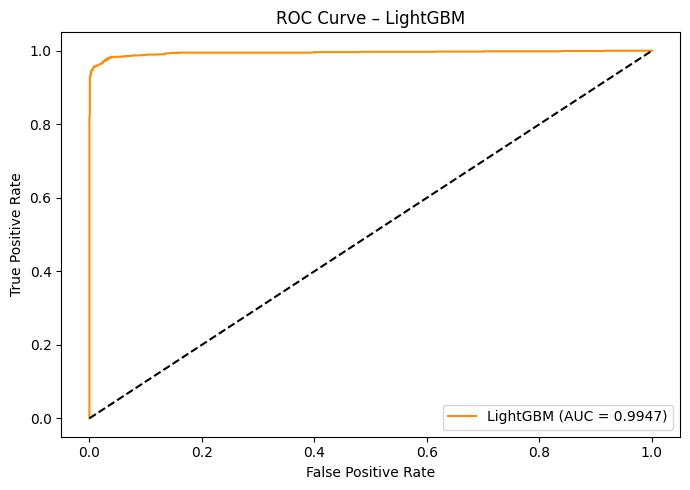

Running ExtraTreesClassifier...

   ExtraTreesClassifier
              precision    recall  f1-score   support

    Low Risk       0.93      0.91      0.92      1325
   High Risk       0.91      0.94      0.92      1324

    accuracy                           0.92      2649
   macro avg       0.92      0.92      0.92      2649
weighted avg       0.92      0.92      0.92      2649

Train Accuracy   : 0.9256
Test  Accuracy   : 0.9234
CV F1 (mean±std) : 0.9300 ± 0.0052
AUC Score        : 0.9702

Overfit Gap (Train - Test): 0.0022
✅ No Overfitting — Model is stable


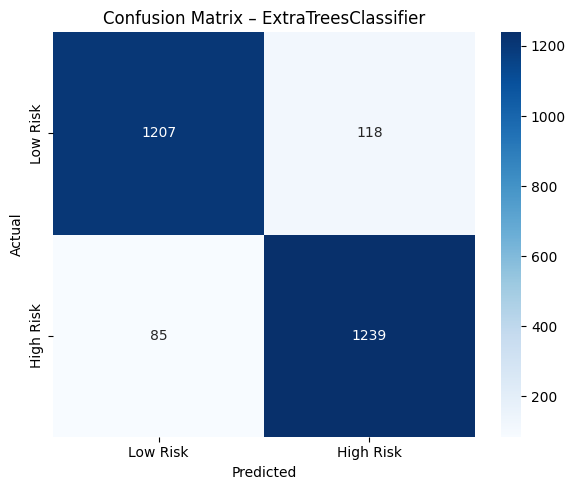

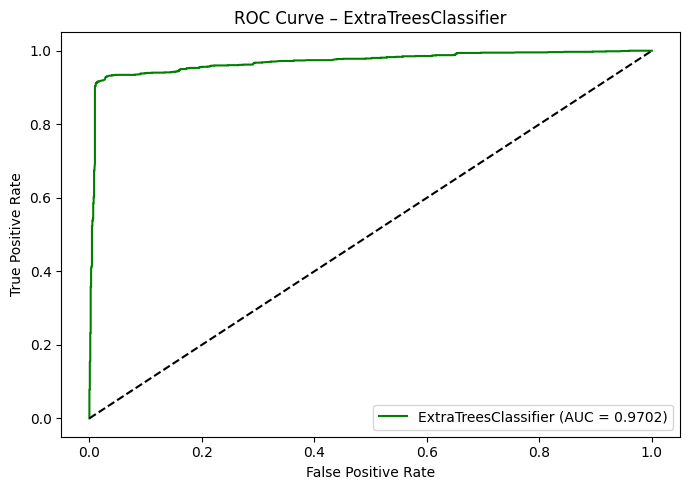


        FINAL MODEL COMPARISON (Leakage Fixed)
                      Train Acc  Test Acc   CV F1     AUC  Overfit Gap
Model                                                                 
XGBoost                  0.9695    0.9634  0.9630  0.9908       0.0061
LightGBM                 0.9777    0.9724  0.9734  0.9947       0.0053
ExtraTreesClassifier     0.9256    0.9234  0.9300  0.9702       0.0022


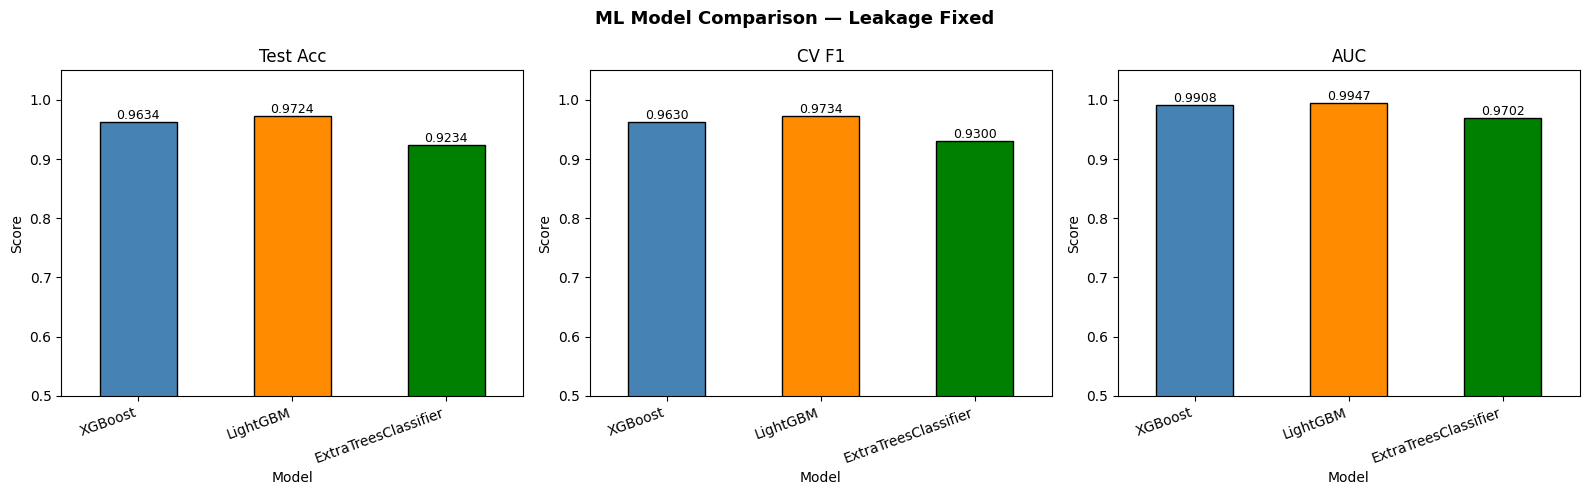

In [ ]:
# ─── RE-DEFINE & RUN ALL 3 ML MODELS (Leakage Fixed) ─────────────────────────
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Helper Function ──
def evaluate_model(model, model_name, color):
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv, scoring='f1_macro', n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred     = model.predict(X_test)
    y_prob     = model.predict_proba(X_test)[:, 1]
    train_acc  = accuracy_score(y_train, model.predict(X_train))
    test_acc   = accuracy_score(y_test, y_pred)
    auc        = roc_auc_score(y_test, y_prob)

    print("\n" + "=" * 55)
    print(f"   {model_name}")
    print("=" * 55)
    print(classification_report(y_test, y_pred,
          target_names=['Low Risk', 'High Risk']))
    print(f"Train Accuracy   : {train_acc:.4f}")
    print(f"Test  Accuracy   : {test_acc:.4f}")
    print(f"CV F1 (mean±std) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"AUC Score        : {auc:.4f}")

    diff = train_acc - test_acc
    print(f"\nOverfit Gap (Train - Test): {diff:.4f}")
    if diff < 0.02:
        print("✅ No Overfitting — Model is stable")
    elif diff < 0.05:
        print("🟡 Slight Overfitting — Acceptable")
    else:
        print("❌ Overfitting Detected — Needs tuning")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low Risk', 'High Risk'],
                yticklabels=['Low Risk', 'High Risk'])
    plt.title(f'Confusion Matrix – {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color=color,
             label=f'{model_name} (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve – {model_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        'Model'      : model_name,
        'Train Acc'  : round(train_acc, 4),
        'Test Acc'   : round(test_acc, 4),
        'CV F1'      : round(cv_scores.mean(), 4),
        'AUC'        : round(auc, 4),
        'Overfit Gap': round(diff, 4)
    }

# ── Define Models ──
xgb_model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = 42,
    n_jobs            = -1
)

lgbm_model = LGBMClassifier(
    n_estimators      = 300,
    max_depth         = 4,
    num_leaves        = 15,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1
)

et_model = ExtraTreesClassifier(
    n_estimators      = 300,
    max_depth         = 10,
    min_samples_split = 10,
    min_samples_leaf  = 5,
    max_features      = 'sqrt',
    class_weight      = 'balanced',
    random_state      = 42,
    n_jobs            = -1
)

# ── Run All 3 ──
results = []

print("Running XGBoost...")
results.append(evaluate_model(xgb_model, 'XGBoost', color='steelblue'))

print("Running LightGBM...")
results.append(evaluate_model(lgbm_model, 'LightGBM', color='darkorange'))

print("Running ExtraTreesClassifier...")
results.append(evaluate_model(et_model, 'ExtraTreesClassifier', color='green'))

# ── Comparison Table ──
results_df = pd.DataFrame(results).set_index('Model')
print("\n" + "=" * 65)
print("        FINAL MODEL COMPARISON (Leakage Fixed)")
print("=" * 65)
print(results_df.to_string())

# ── Comparison Chart ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors  = ['steelblue', 'darkorange', 'green']
metrics = ['Test Acc', 'CV F1', 'AUC']

for i, metric in enumerate(metrics):
    results_df[metric].plot(
        kind='bar', ax=axes[i],
        color=colors, edgecolor='black', width=0.5
    )
    axes[i].set_title(metric)
    axes[i].set_ylim(0.5, 1.05)
    axes[i].set_xticklabels(results_df.index, rotation=20, ha='right')
    axes[i].set_ylabel('Score')
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.4f}',
                         (p.get_x() + p.get_width() / 2, p.get_height()),
                         ha='center', va='bottom', fontsize=9)

plt.suptitle('ML Model Comparison — Leakage Fixed',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ─── DEEP LEARNING SETUP ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    LSTM, GRU
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow  : {tf.__version__}")
print(f"Train shape : {X_train.shape}")
print(f"Test  shape : {X_test.shape}")
print(f"Features    : {feature_names}")

# ── Callbacks ──
def get_callbacks():
    return [
        EarlyStopping(
            monitor              = 'val_loss',
            patience             = 15,
            restore_best_weights = True,
            verbose              = 1
        ),
        ReduceLROnPlateau(
            monitor  = 'val_loss',
            factor   = 0.5,
            patience = 7,
            min_lr   = 1e-6,
            verbose  = 1
        )
    ]

# ── Training History Plot ──
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{model_name} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{model_name} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(f'{model_name} — Training History',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ── Evaluate DL Model ──
dl_results = []

def evaluate_dl_model(model, model_name, color,
                      history, X_tr, X_te):
    y_prob    = model.predict(X_te).ravel()
    y_pred    = (y_prob >= 0.5).astype(int)
    y_prob_tr = model.predict(X_tr).ravel()
    y_pred_tr = (y_prob_tr >= 0.5).astype(int)

    train_acc = accuracy_score(y_train, y_pred_tr)
    test_acc  = accuracy_score(y_test,  y_pred)
    auc       = roc_auc_score(y_test,   y_prob)
    diff      = train_acc - test_acc

    print("\n" + "=" * 55)
    print(f"   {model_name}")
    print("=" * 55)
    print(classification_report(y_test, y_pred,
          target_names=['Low Risk', 'High Risk']))
    print(f"Train Accuracy   : {train_acc:.4f}")
    print(f"Test  Accuracy   : {test_acc:.4f}")
    print(f"AUC Score        : {auc:.4f}")
    print(f"\nOverfit Gap (Train - Test): {diff:.4f}")
    if diff < 0.02:
        print("✅ No Overfitting — Model is stable")
    elif diff < 0.05:
        print("🟡 Slight Overfitting — Acceptable")
    else:
        print("❌ Overfitting Detected")

    # Training History
    plot_history(history, model_name)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low Risk', 'High Risk'],
                yticklabels=['Low Risk', 'High Risk'])
    plt.title(f'Confusion Matrix – {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color=color,
             label=f'{model_name} (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve – {model_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    dl_results.append({
        'Model'      : model_name,
        'Train Acc'  : round(train_acc, 4),
        'Test Acc'   : round(test_acc,  4),
        'AUC'        : round(auc, 4),
        'Overfit Gap': round(diff, 4)
    })

TensorFlow  : 2.20.0
Train shape : (10592, 8)
Test  shape : (1524, 8)
Features    : ['PatientAge', 'Q_wave', 'R_wave', 'S_wave', 'T_wave', 'PR_Interval', 'QTc_Interval', 'ST _segment']


Training ANN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 11,969 (46.75 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.6861 - loss: 0.6120 - val_accuracy: 0.1142 - val_loss: 0.8500 - learning_rate: 0.0010
Epoch 2/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8506 - loss: 0.3461 - val_accuracy: 0.1840 - val_loss: 1.0677 - learning_rate: 0.0010
Epoch 3/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9070 - loss: 0.2358 - val_accuracy: 0.2246 - val_loss: 1.6160 - learning_rate: 0.0010
Epoch 4/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9313 - loss: 0.1798 - val_accuracy: 0.2506 - val_loss: 1.4636 - learning_rate: 0.0010
Epoch 5/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9396 - loss: 0.1575 - val_accuracy: 0.5540 - val_loss: 0.7350 - learning_rate: 0.0010
Epoch 6/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9527 - loss: 0.1313 - val_accuracy: 0.8952 - val_loss: 0.3440 - learning_rate: 0.0010
Epoch 7/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9529 - los

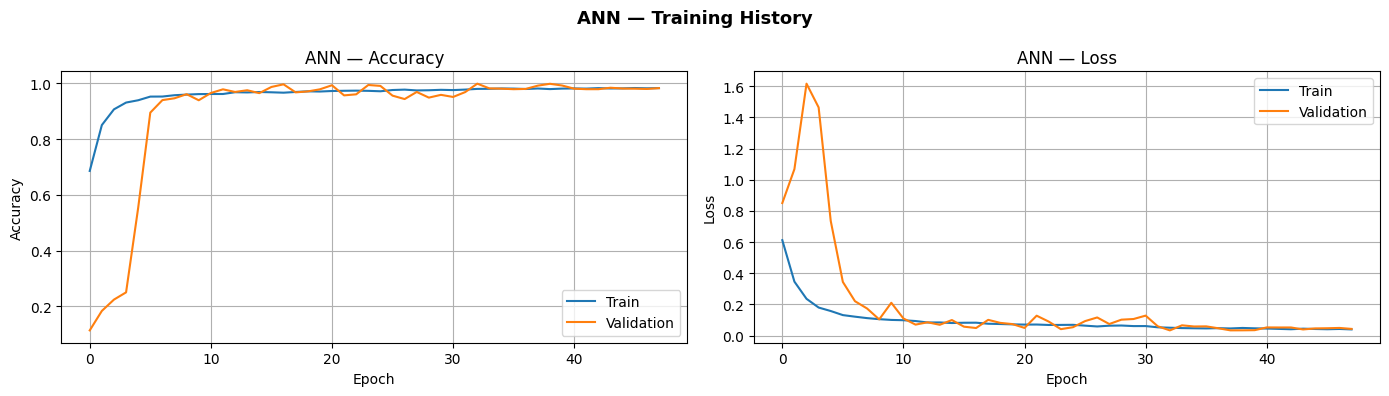

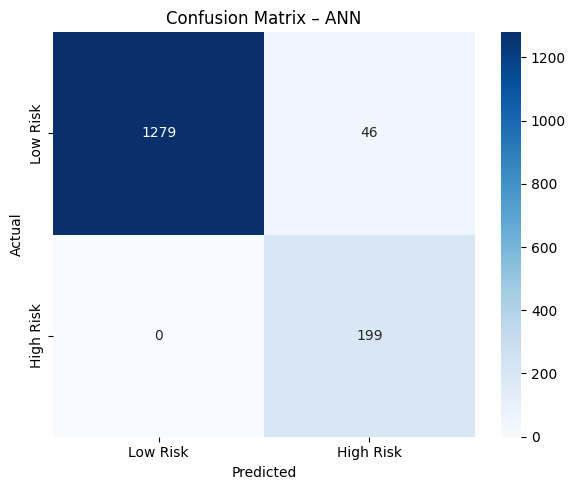

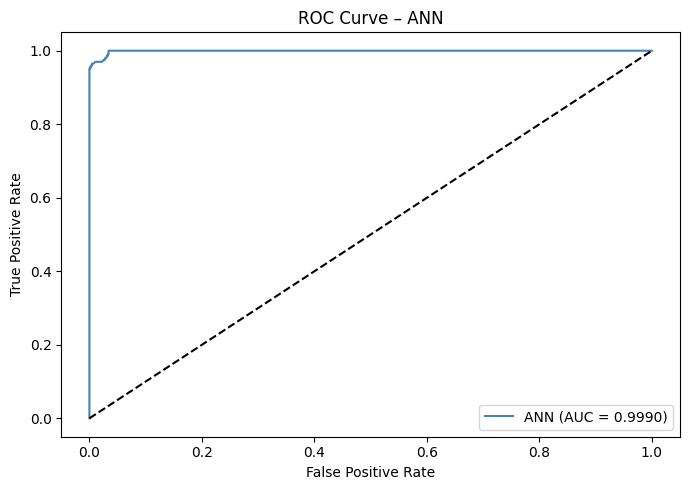

In [ ]:
# ─── MODEL 1: ANN ─────────────────────────────────────────────────────────────
print("Training ANN...")

n_features = X_train.shape[1]

ann_model = Sequential([
    Dense(128, activation='relu',
          input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
], name='ANN')

ann_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

ann_model.summary()

ann_history = ann_model.fit(
    X_train, y_train,
    epochs           = 100,
    batch_size       = 64,
    validation_split = 0.2,
    callbacks        = get_callbacks(),
    verbose          = 1
)

# ANN uses 2D data directly
evaluate_dl_model(
    ann_model, 'ANN', color='steelblue',
    history=ann_history,
    X_tr=X_train, X_te=X_test
)

Training Fixed LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 8, 32)          │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,841 (30.63 KB)

 Trainable params: 7,809 (30.50 KB)

 Non-trainable params: 32 (128.00 B)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.6088 - loss: 1.2053 - val_accuracy: 4.7192e-04 - val_loss: 1.2412 - learning_rate: 5.0000e-04
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6414 - loss: 1.0442 - val_accuracy: 0.0019 - val_loss: 1.2061 - learning_rate: 5.0000e-04
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6472 - loss: 0.9407 - val_accuracy: 0.0028 - val_loss: 1.1701 - learning_rate: 5.0000e-04
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6465 - loss: 0.8646 - val_accuracy: 0.0028 - val_loss: 1.1271 - learning_rate: 5.0000e-04
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6488 - loss: 0.8100 - val_accuracy: 0.0123 - val_loss: 1.1005 - learning_rate: 5.0000e-04
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6494 - loss: 0.7696 - val_accuracy: 0.0302 - val_loss: 1.0657 - learning_rate: 5.0000e-04
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accur

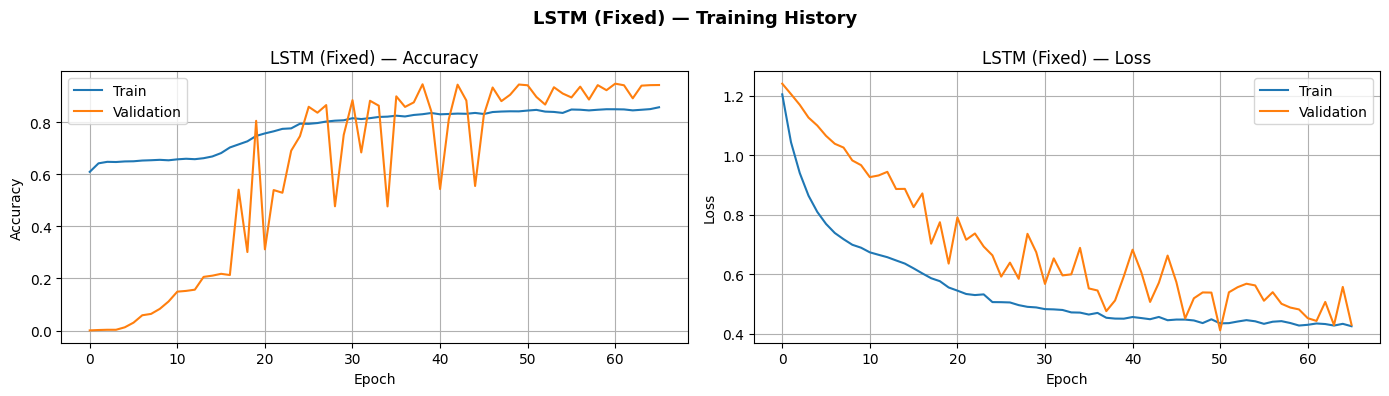

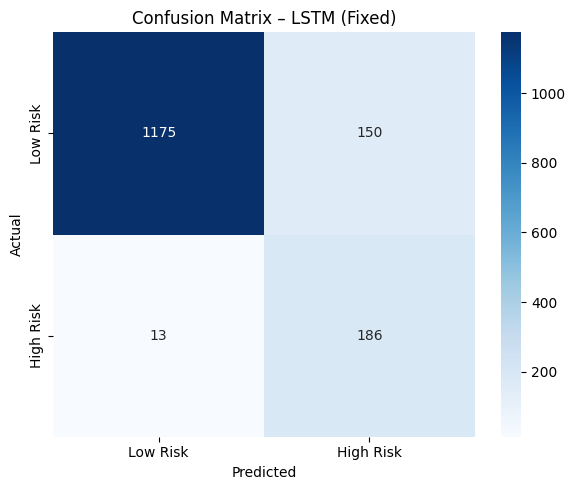

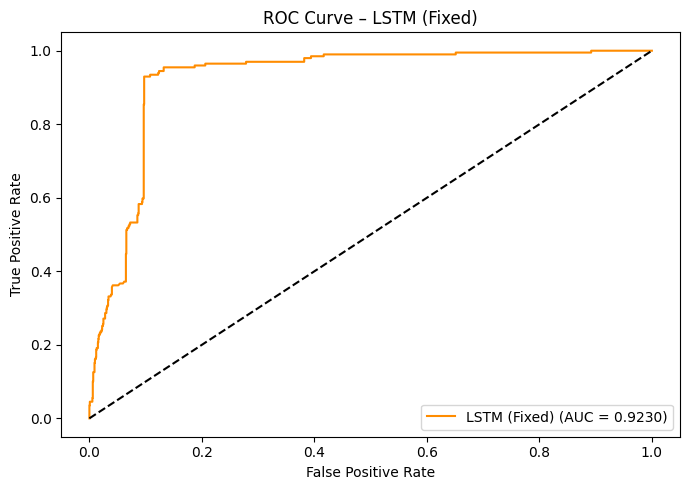

In [ ]:
# ─── FIXED LSTM ───────────────────────────────────────────────────────────────
from tensorflow.keras.regularizers import l2

print("Training Fixed LSTM...")

lstm_model = Sequential([
    LSTM(32,                              # 64→32 (কমালাম)
         return_sequences=True,
         kernel_regularizer=l2(0.01),    # L2 regularization যোগ করলাম
         input_shape=(n_features, 1)),
    Dropout(0.5),                         # 0.3→0.5 (বাড়ালাম)

    LSTM(16,                              # 32→16 (কমালাম)
         return_sequences=False,
         kernel_regularizer=l2(0.01)),
    Dropout(0.5),

    Dense(16, activation='relu',          # 32→16
          kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
], name='LSTM_Fixed')

lstm_model.compile(
    optimizer = Adam(learning_rate=0.0005),  # 0.001→0.0005 (slower)
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

lstm_model.summary()

lstm_history = lstm_model.fit(
    X_train_3d, y_train,
    epochs           = 100,
    batch_size       = 128,               # 64→128 (বাড়ালাম)
    validation_split = 0.2,
    callbacks        = get_callbacks(),
    verbose          = 1
)

evaluate_dl_model(
    lstm_model, 'LSTM (Fixed)', color='darkorange',
    history=lstm_history,
    X_tr=X_train_3d, X_te=X_test_3d
)

Training Fixed GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "GRU_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 8, 32)          │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 16)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,113 (23.88 KB)

 Trainable params: 6,081 (23.75 KB)

 Non-trainable params: 32 (128.00 B)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5663 - loss: 1.2765 - val_accuracy: 0.0028 - val_loss: 1.2358 - learning_rate: 5.0000e-04
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6108 - loss: 1.1174 - val_accuracy: 0.0099 - val_loss: 1.2258 - learning_rate: 5.0000e-04
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6433 - loss: 1.0073 - val_accuracy: 0.0396 - val_loss: 1.1989 - learning_rate: 5.0000e-04
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.6443 - loss: 0.9384 - val_accuracy: 0.0585 - val_loss: 1.1694 - learning_rate: 5.0000e-04
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6471 - loss: 0.8870 - val_accuracy: 0.0552 - val_loss: 1.1570 - learning_rate: 5.0000e-04
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6495 - loss: 0.8422 - val_accuracy: 0.0689 - val_loss: 1.1287 - learning_rate: 5.0000e-04
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 

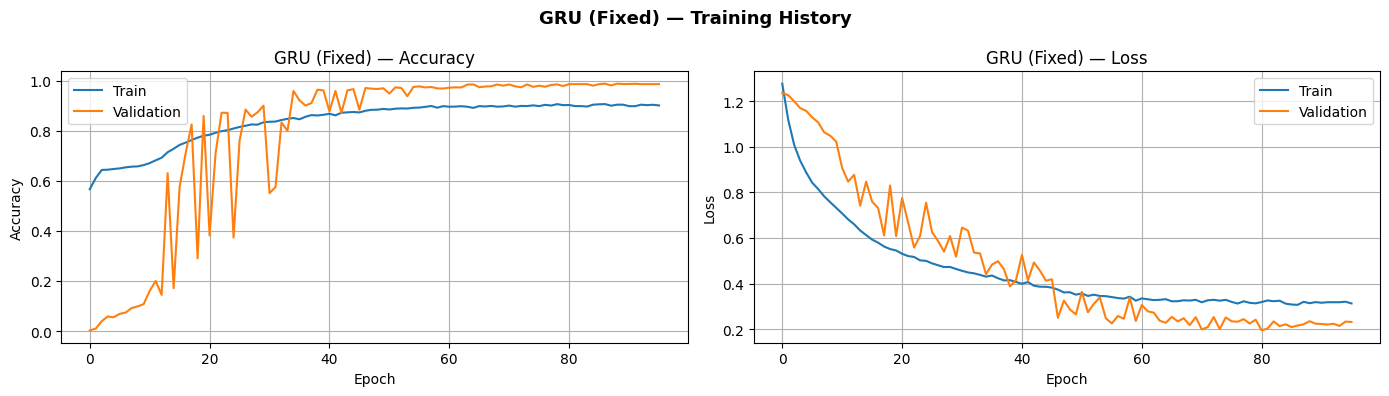

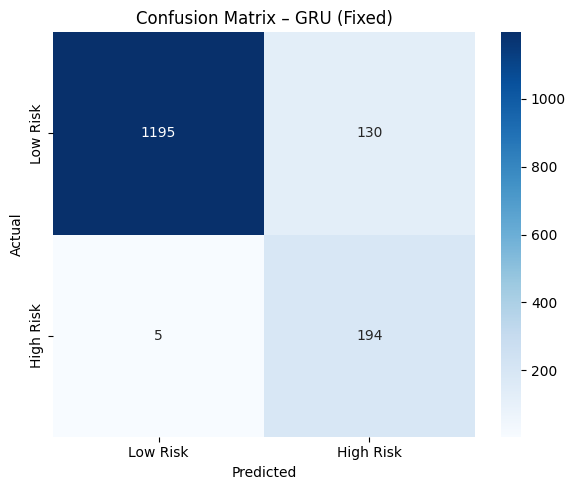

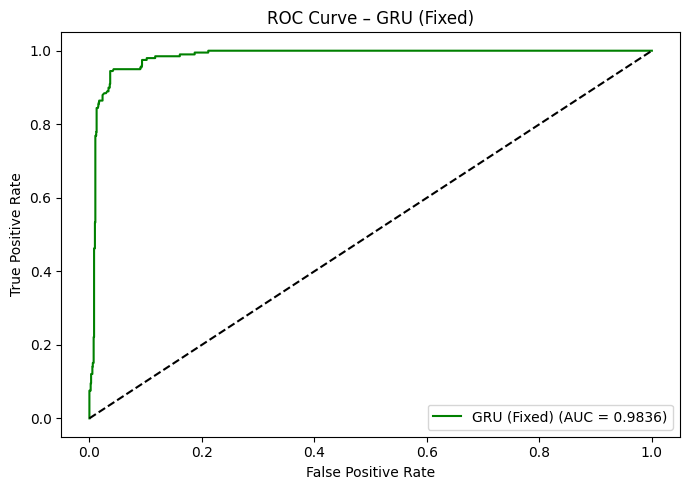

In [ ]:
# ─── FIXED GRU ────────────────────────────────────────────────────────────────
print("Training Fixed GRU...")

gru_model = Sequential([
    GRU(32,                               # 64→32
        return_sequences=True,
        kernel_regularizer=l2(0.01),
        input_shape=(n_features, 1)),
    Dropout(0.5),

    GRU(16,                               # 32→16
        return_sequences=False,
        kernel_regularizer=l2(0.01)),
    Dropout(0.5),

    Dense(16, activation='relu',
          kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
], name='GRU_Fixed')

gru_model.compile(
    optimizer = Adam(learning_rate=0.0005),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

gru_model.summary()

gru_history = gru_model.fit(
    X_train_3d, y_train,
    epochs           = 100,
    batch_size       = 128,
    validation_split = 0.2,
    callbacks        = get_callbacks(),
    verbose          = 1
)

evaluate_dl_model(
    gru_model, 'GRU (Fixed)', color='green',
    history=gru_history,
    X_tr=X_train_3d, X_te=X_test_3d
)


      DEEP LEARNING COMPARISON (Correct Pipeline)
              Train Acc  Test Acc     AUC  Overfit Gap
Model                                                 
ANN              0.9858    0.9698  0.9990       0.0160
LSTM             0.8828    0.7986  0.9789       0.0843
GRU              0.8405    0.7329  0.9727       0.1076
LSTM (Fixed)     0.9172    0.8930  0.9230       0.0242
GRU (Fixed)      0.9472    0.9114  0.9836       0.0358


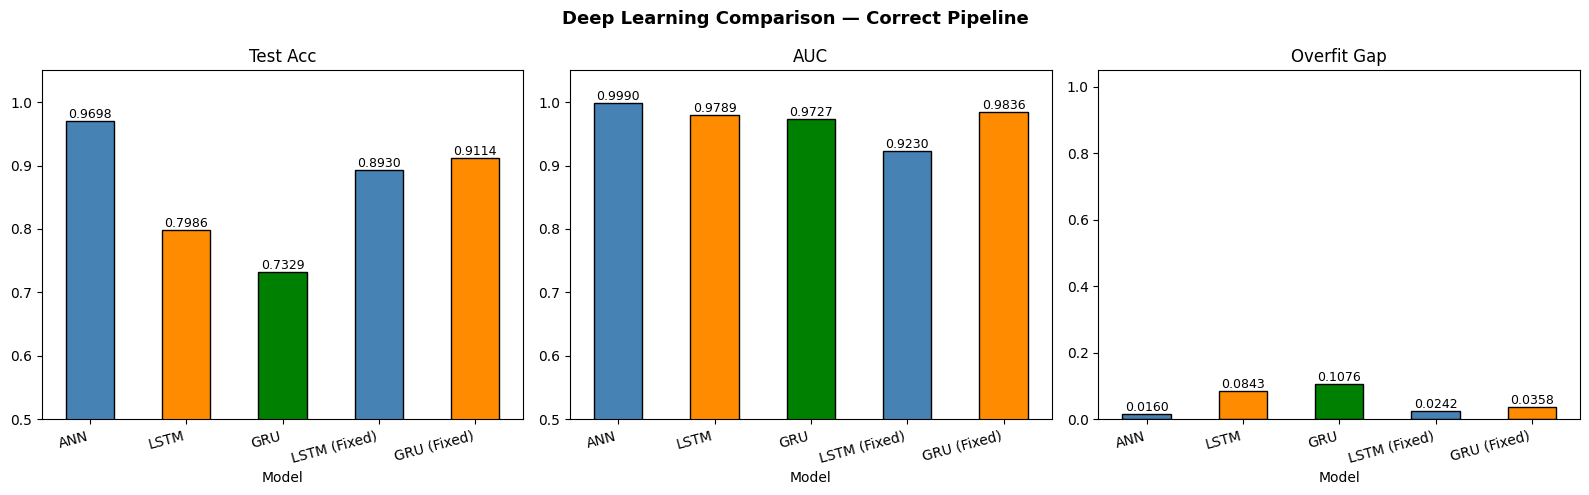

In [ ]:
# ─── DEEP LEARNING COMPARISON ─────────────────────────────────────────────────
dl_df = pd.DataFrame(dl_results).set_index('Model')

print("\n" + "=" * 60)
print("      DEEP LEARNING COMPARISON (Correct Pipeline)")
print("=" * 60)
print(dl_df.to_string())

# Chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors  = ['steelblue', 'darkorange', 'green']
metrics = ['Test Acc', 'AUC', 'Overfit Gap']

for i, metric in enumerate(metrics):
    dl_df[metric].plot(
        kind='bar', ax=axes[i],
        color=colors, edgecolor='black', width=0.5
    )
    axes[i].set_title(metric)
    axes[i].set_ylim(0 if metric == 'Overfit Gap' else 0.5, 1.05)
    axes[i].set_xticklabels(dl_df.index, rotation=15, ha='right')
    for p in axes[i].patches:
        axes[i].annotate(
            f'{p.get_height():.4f}',
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center', va='bottom', fontsize=9
        )

plt.suptitle('Deep Learning Comparison — Correct Pipeline',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ─── CNN SETUP ────────────────────────────────────────────────────────────────
from tensorflow.keras.layers import (
    Conv1D, GlobalAveragePooling1D,
    Bidirectional, LSTM, GRU,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.regularizers import l2

# X_train_3d, X_test_3d already defined
print(f"CNN Input shape : {X_train_3d.shape}")

cnn_results = []

def evaluate_cnn_model(model, model_name, color, history):
    y_prob    = model.predict(X_test_3d).ravel()
    y_pred    = (y_prob >= 0.5).astype(int)
    y_prob_tr = model.predict(X_train_3d).ravel()
    y_pred_tr = (y_prob_tr >= 0.5).astype(int)

    train_acc = accuracy_score(y_train, y_pred_tr)
    test_acc  = accuracy_score(y_test,  y_pred)
    auc       = roc_auc_score(y_test,   y_prob)
    diff      = train_acc - test_acc

    print("\n" + "=" * 55)
    print(f"   {model_name}")
    print("=" * 55)
    print(classification_report(y_test, y_pred,
          target_names=['Low Risk', 'High Risk']))
    print(f"Train Accuracy   : {train_acc:.4f}")
    print(f"Test  Accuracy   : {test_acc:.4f}")
    print(f"AUC Score        : {auc:.4f}")
    print(f"\nOverfit Gap (Train - Test): {diff:.4f}")
    if diff < 0.02:
        print("✅ No Overfitting — Model is stable")
    elif diff < 0.05:
        print("🟡 Slight Overfitting — Acceptable")
    else:
        print("❌ Overfitting Detected")

    plot_history(history, model_name)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low Risk', 'High Risk'],
                yticklabels=['Low Risk', 'High Risk'])
    plt.title(f'Confusion Matrix – {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color=color,
             label=f'{model_name} (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve – {model_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    cnn_results.append({
        'Model'      : model_name,
        'Train Acc'  : round(train_acc, 4),
        'Test Acc'   : round(test_acc,  4),
        'AUC'        : round(auc, 4),
        'Overfit Gap': round(diff, 4)
    })

CNN Input shape : (10592, 8, 1)


Training Conv1D CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Conv1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 8, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 8, 32)          │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,985 (39.00 KB)

 Trainable params: 9,729 (38.00 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.6680 - loss: 1.6278 - val_accuracy: 0.1081 - val_loss: 1.5937 - learning_rate: 5.0000e-04
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7841 - loss: 1.2387 - val_accuracy: 1.0000 - val_loss: 1.1403 - learning_rate: 5.0000e-04
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8480 - loss: 0.9474 - val_accuracy: 1.0000 - val_loss: 0.7809 - learning_rate: 5.0000e-04
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8753 - loss: 0.7349 - val_accuracy: 1.0000 - val_loss: 0.5989 - learning_rate: 5.0000e-04
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8930 - loss: 0.5900 - val_accuracy: 1.0000 - val_loss: 0.4999 - learning_rate: 5.0000e-04
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9009 - loss: 0.4904 - val_accuracy: 1.0000 - val_loss: 0.4508 - learning_rate: 5.0000e-04
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy:

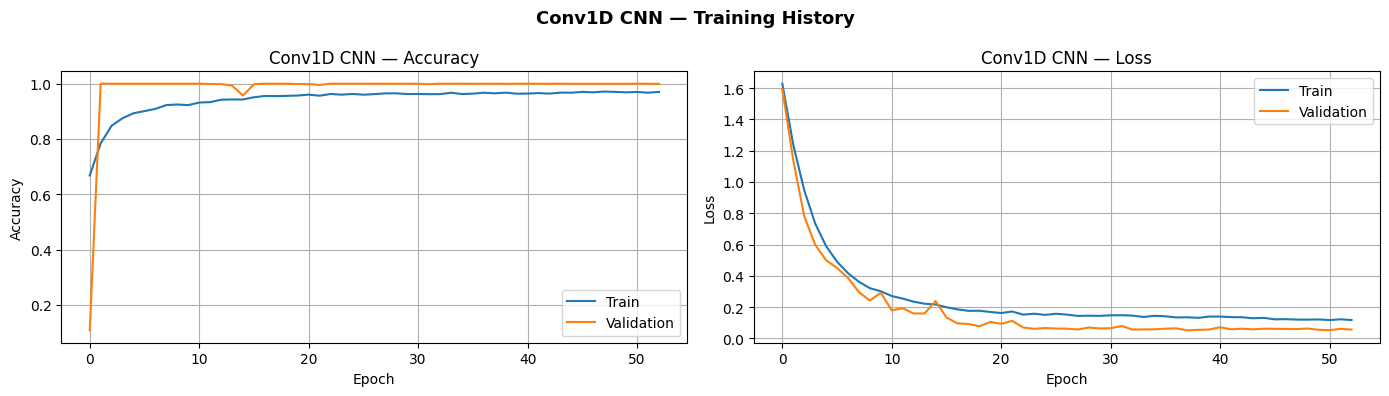

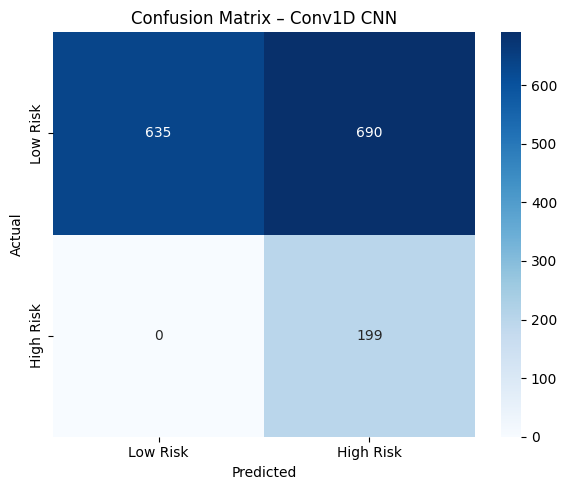

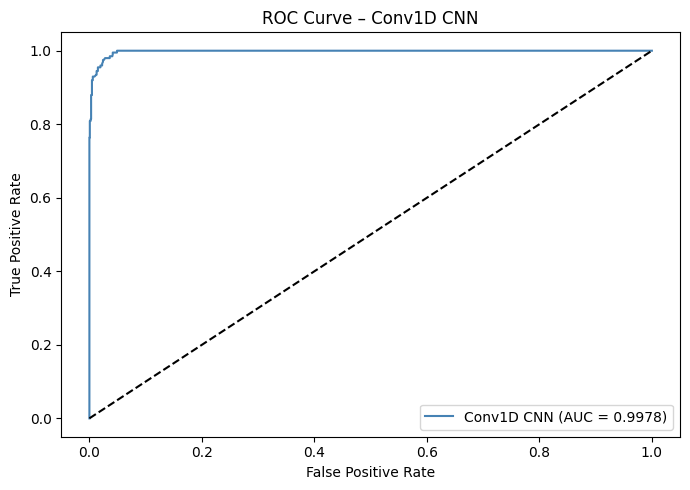

In [ ]:
# ─── CNN MODEL 1: Conv1D ──────────────────────────────────────────────────────
print("Training Conv1D CNN...")

conv1d_model = Sequential([
    Conv1D(filters=32, kernel_size=2, activation='relu',
           padding='same',
           kernel_regularizer=l2(0.01),
           input_shape=(n_features, 1)),
    BatchNormalization(),
    Dropout(0.4),

    Conv1D(filters=64, kernel_size=2, activation='relu',
           padding='same',
           kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.4),

    Conv1D(filters=32, kernel_size=2, activation='relu',
           padding='same',
           kernel_regularizer=l2(0.01)),
    BatchNormalization(),

    GlobalAveragePooling1D(),

    Dense(32, activation='relu',
          kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='Conv1D_CNN')

conv1d_model.compile(
    optimizer = Adam(learning_rate=0.0005),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

conv1d_model.summary()

conv1d_history = conv1d_model.fit(
    X_train_3d, y_train,
    epochs           = 100,
    batch_size       = 128,
    validation_split = 0.2,
    callbacks        = get_callbacks(),
    verbose          = 1
)

evaluate_cnn_model(conv1d_model, 'Conv1D CNN',
                   color='steelblue', history=conv1d_history)

Training Conv1D + BiLSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Conv1D_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 5, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 5, 128)         │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 5, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,577 (471.00 KB)

 Trainable params: 120,129 (469.25 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.6285 - loss: 0.6795 - val_accuracy: 0.5092 - val_loss: 0.7326 - learning_rate: 0.0010
Epoch 2/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7652 - loss: 0.5075 - val_accuracy: 0.5092 - val_loss: 1.5900 - learning_rate: 0.0010
Epoch 3/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8248 - loss: 0.4244 - val_accuracy: 0.5092 - val_loss: 2.4836 - learning_rate: 0.0010
Epoch 4/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8563 - loss: 0.3808 - val_accuracy: 0.6630 - val_loss: 1.0383 - learning_rate: 0.0010
Epoch 5/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8720 - loss: 0.3543 - val_accuracy: 0.7735 - val_loss: 0.6062 - learning_rate: 0.0010
Epoch 6/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8780 - loss: 0.3403 - val_accuracy: 0.8839 - val_loss: 0.3317 - learning_rate: 0.0010
Epoch 7/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8859 - 

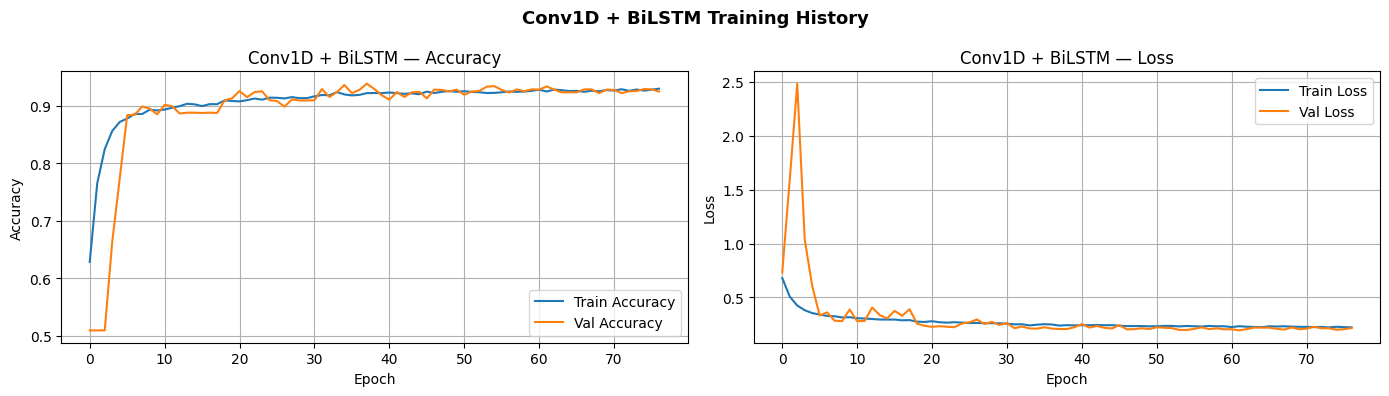

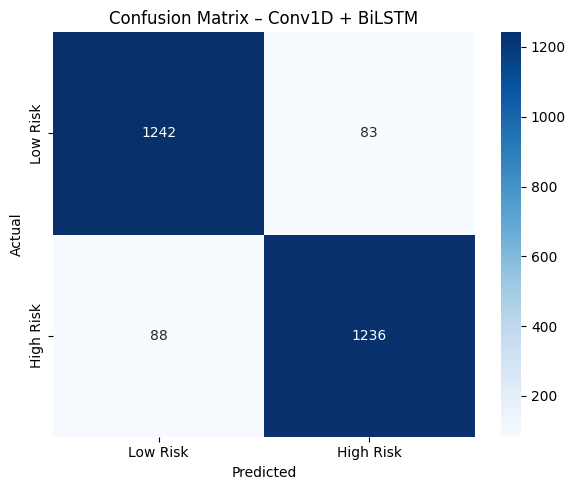

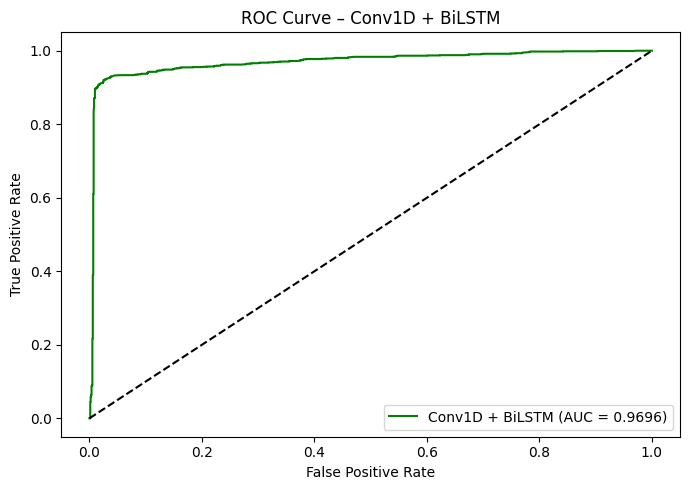

Training Conv1D + LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Conv1D_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 8, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 8, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,665 (69.00 KB)

 Trainable params: 17,441 (68.13 KB)

 Non-trainable params: 224 (896.00 B)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5835 - loss: 2.1054 - val_accuracy: 0.0024 - val_loss: 1.9958 - learning_rate: 5.0000e-04
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6672 - loss: 1.7797 - val_accuracy: 0.9278 - val_loss: 1.7198 - learning_rate: 5.0000e-04
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7556 - loss: 1.4946 - val_accuracy: 1.0000 - val_loss: 1.2730 - learning_rate: 5.0000e-04
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8073 - loss: 1.2696 - val_accuracy: 1.0000 - val_loss: 0.9845 - learning_rate: 5.0000e-04
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8476 - loss: 1.0841 - val_accuracy: 1.0000 - val_loss: 0.7512 - learning_rate: 5.0000e-04
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8678 - loss: 0.9379 - val_accuracy: 1.0000 - val_loss: 0.6089 - learning_rate: 5.0000e-04
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 

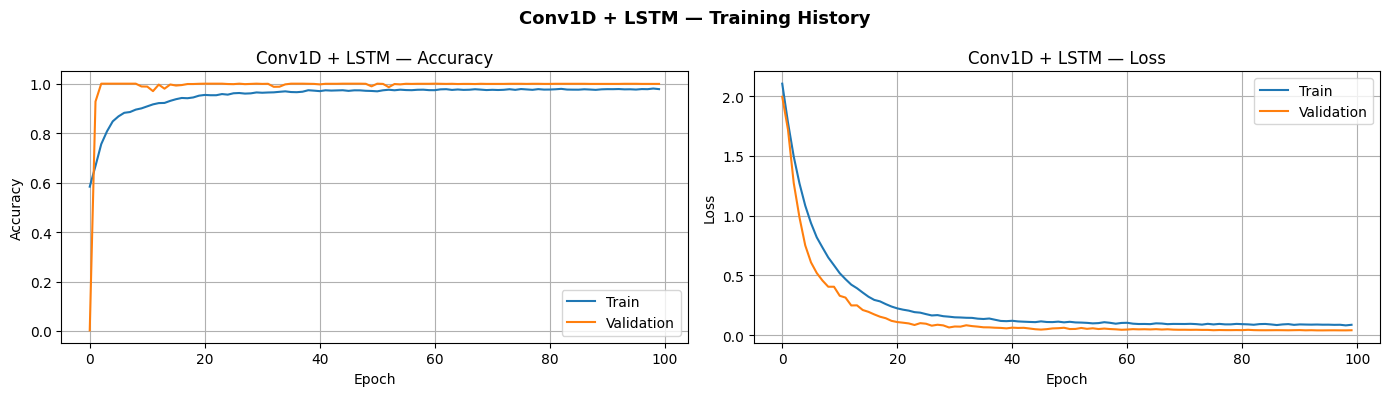

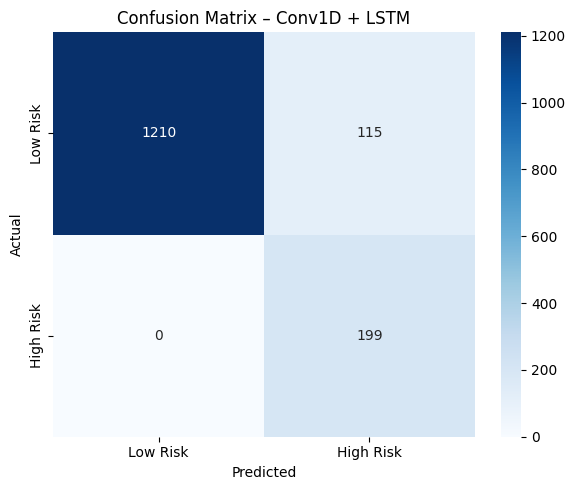

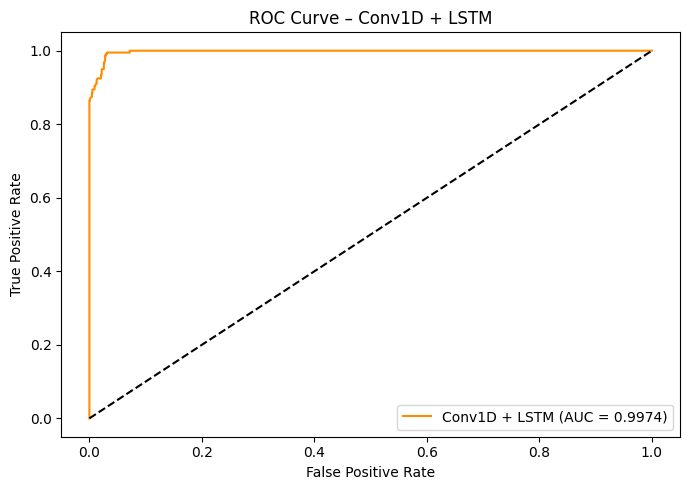

In [ ]:
# ─── CNN MODEL 2: Conv1D + LSTM ───────────────────────────────────────────────
print("Training Conv1D + LSTM...")

conv_lstm_model = Sequential([
    Conv1D(filters=32, kernel_size=2, activation='relu',
           padding='same',
           kernel_regularizer=l2(0.01),
           input_shape=(n_features, 1)),
    BatchNormalization(),
    Dropout(0.4),

    Conv1D(filters=64, kernel_size=2, activation='relu',
           padding='same',
           kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.4),

    LSTM(32, return_sequences=False,
         kernel_regularizer=l2(0.01)),
    Dropout(0.4),

    Dense(16, activation='relu',
          kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
], name='Conv1D_LSTM')

conv_lstm_model.compile(
    optimizer = Adam(learning_rate=0.0005),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

conv_lstm_model.summary()

conv_lstm_history = conv_lstm_model.fit(
    X_train_3d, y_train,
    epochs           = 100,
    batch_size       = 128,
    validation_split = 0.2,
    callbacks        = get_callbacks(),
    verbose          = 1
)

evaluate_cnn_model(conv_lstm_model, 'Conv1D + LSTM',
                   color='darkorange', history=conv_lstm_history)

Training Conv1D + BiLSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Conv1D_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 8, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 8, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,593 (119.50 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 224 (896.00 B)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.6050 - loss: 2.9904 - val_accuracy: 0.0354 - val_loss: 2.8174 - learning_rate: 5.0000e-04
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7142 - loss: 2.4367 - val_accuracy: 0.0552 - val_loss: 2.5511 - learning_rate: 5.0000e-04
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7576 - loss: 2.0591 - val_accuracy: 0.2143 - val_loss: 2.1869 - learning_rate: 5.0000e-04
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7965 - loss: 1.7496 - val_accuracy: 0.9788 - val_loss: 1.6636 - learning_rate: 5.0000e-04
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8200 - loss: 1.5052 - val_accuracy: 1.0000 - val_loss: 1.2809 - learning_rate: 5.0000e-04
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8421 - loss: 1.2936 - val_accuracy: 0.9976 - val_loss: 1.0660 - learning_rate: 5.0000e-04
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 

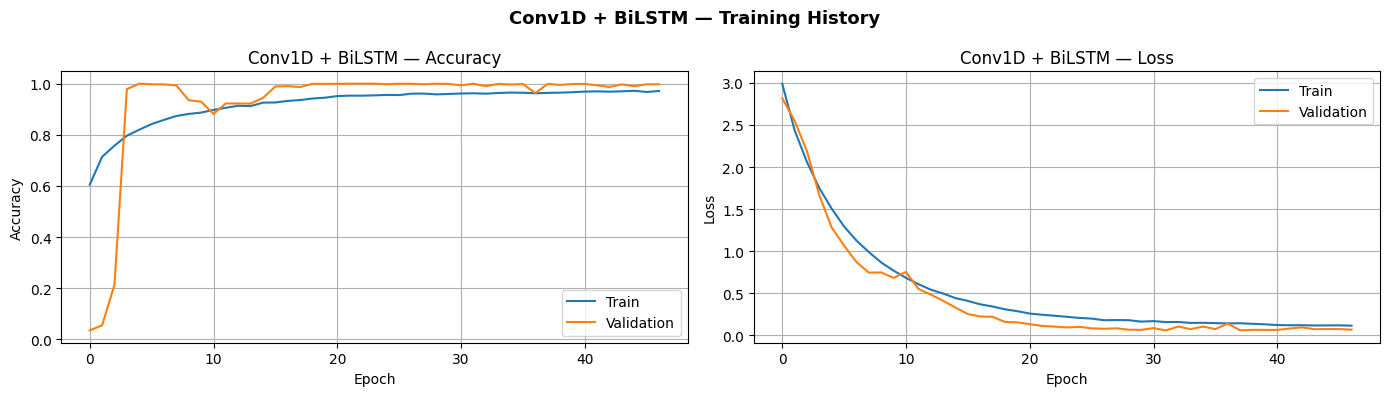

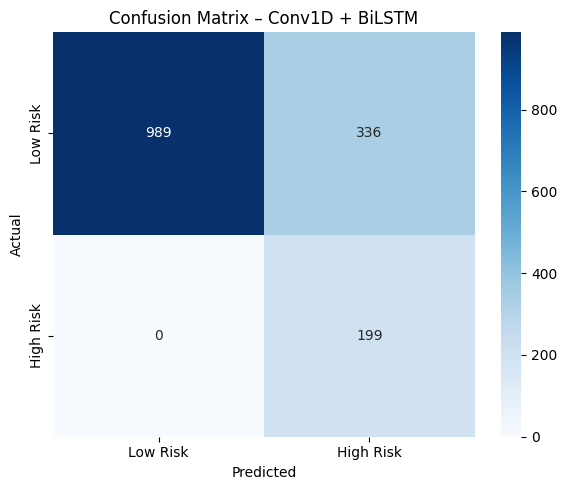

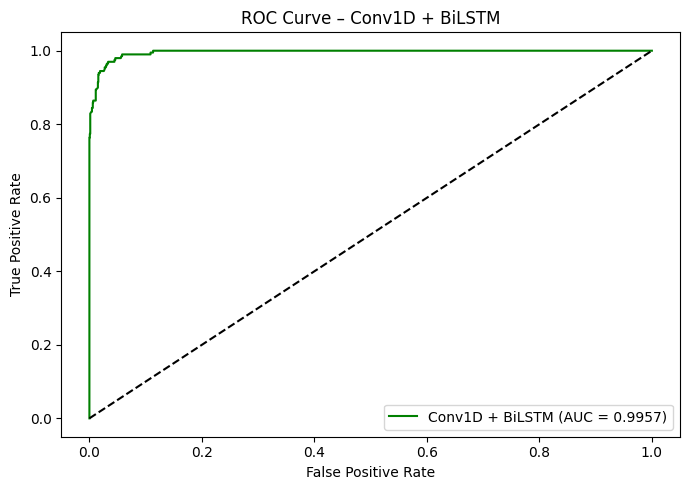

In [ ]:
# ─── CNN MODEL 3: Conv1D + BiLSTM ─────────────────────────────────────────────
print("Training Conv1D + BiLSTM...")

conv_bilstm_model = Sequential([
    Conv1D(filters=32, kernel_size=2, activation='relu',
           padding='same',
           kernel_regularizer=l2(0.01),
           input_shape=(n_features, 1)),
    BatchNormalization(),
    Dropout(0.4),

    Conv1D(filters=64, kernel_size=2, activation='relu',
           padding='same',
           kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.4),

    Bidirectional(LSTM(32, return_sequences=False,
                       kernel_regularizer=l2(0.01))),
    Dropout(0.4),

    Dense(16, activation='relu',
          kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
], name='Conv1D_BiLSTM')

conv_bilstm_model.compile(
    optimizer = Adam(learning_rate=0.0005),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

conv_bilstm_model.summary()

conv_bilstm_history = conv_bilstm_model.fit(
    X_train_3d, y_train,
    epochs           = 100,
    batch_size       = 128,
    validation_split = 0.2,
    callbacks        = get_callbacks(),
    verbose          = 1
)

evaluate_cnn_model(conv_bilstm_model, 'Conv1D + BiLSTM',
                   color='green', history=conv_bilstm_history)


         CNN MODEL COMPARISON (Correct Pipeline)
                 Train Acc  Test Acc     AUC  Overfit Gap
Model                                                    
Conv1D CNN          0.7472    0.5472  0.9978       0.1999
Conv1D + LSTM       0.9578    0.9245  0.9974       0.0333
Conv1D + BiLSTM     0.8751    0.7795  0.9957       0.0956


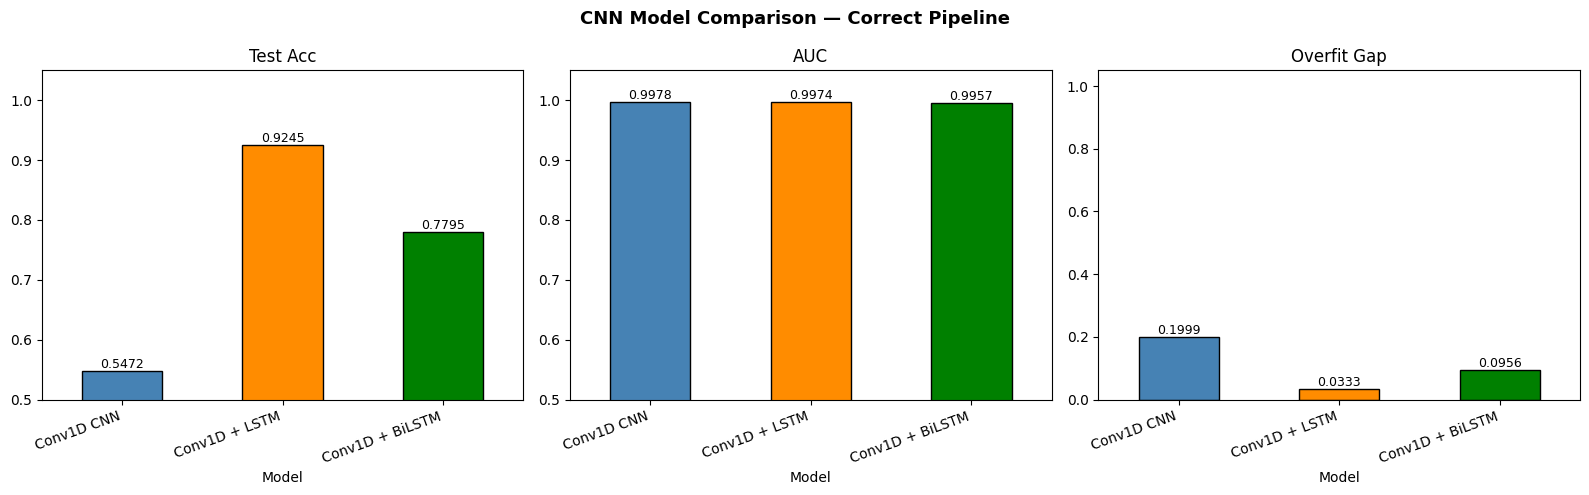

In [ ]:
# ─── CNN COMPARISON TABLE ─────────────────────────────────────────────────────
cnn_df = pd.DataFrame(cnn_results).set_index('Model')

print("\n" + "=" * 60)
print("         CNN MODEL COMPARISON (Correct Pipeline)")
print("=" * 60)
print(cnn_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors  = ['steelblue', 'darkorange', 'green']
metrics = ['Test Acc', 'AUC', 'Overfit Gap']

for i, metric in enumerate(metrics):
    cnn_df[metric].plot(
        kind='bar', ax=axes[i],
        color=colors, edgecolor='black', width=0.5
    )
    axes[i].set_title(metric)
    axes[i].set_ylim(0 if metric == 'Overfit Gap' else 0.5, 1.05)
    axes[i].set_xticklabels(cnn_df.index, rotation=20, ha='right')
    for p in axes[i].patches:
        axes[i].annotate(
            f'{p.get_height():.4f}',
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center', va='bottom', fontsize=9
        )

plt.suptitle('CNN Model Comparison — Correct Pipeline',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()